# Early CD8<sup>+</sup> T cell activation as a multiview hypergraph

This tutorial fits a **multiview hypergraph trajectory** to 250 naive OT-I CD8<sup>+</sup>
T cells sampled 0, 1, 3 and 6 h after stimulation
([Richard et al. 2018, *Nat Immunol*](https://doi.org/10.1038/s41590-018-0160-9)),
and then asks what the model is actually made of.

**Why this dataset.** Four surface proteins (CD69, CD25, CD44, CD62L) were
measured per cell by index sorting. They are *not* derived from the
transcriptome, so they are a genuinely held-out axis to score a pseudotime
against — which is rare, and is the reason this dataset is used here rather than
a larger one.

**What is different about the hypergraph.** A k-NN graph connects cells
pairwise. A hypergraph edge connects *a set of cells that share a programme* — a
TF regulon being active, a pathway being in a given activity bin, a gene being
expressed. The pseudotime is read off the fused hypergraph, and because every
edge carries a name, the axis can be **attributed back to named programmes**.
That attribution, not raw pseudotime accuracy, is the point of the method.

**What this tutorial covers.** Loading the data, building three views over it,
fusing them, reading a pseudotime off the fusion, checking that pseudotime
against measurements the model never saw, and decomposing the axis into the named
hyperedges that build it. Every figure is a `pseudoembed.plotting` call.

## 0. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import spearmanr

import pseudoembed
import pseudoembed.plotting as pp
from pseudoembed.plotting import style as S

SEED = 0
np.random.seed(SEED)
sc.settings.verbosity = 1
warnings.simplefilter("ignore", FutureWarning)
S.apply()  # colourblind-safe journal theme; every figure below inherits it

print("pseudoembed", pseudoembed.__version__)

pseudoembed 0.1.0


## 1. Load the data

`pseudoembed.richard2018()` downloads E-MTAB-6051 from EBI on first call (~30 MB
of text, ~15 s) and caches it; later calls are instant. Nothing is redistributed
with the package.

It returns the **high-affinity (N4) arm plus the unstimulated baseline**. That is
one arm of a four-arm study, and the docstring explains why: the reduced-affinity
and non-binding arms were harvested at 6 h *only*, so they cannot supply a second
time course.

In [2]:
adata = pseudoembed.richard2018()
adata

Richard 2018 (E-MTAB-6051), cache: ~/.cache/pseudoembed
  250 QC-passing cells (arm='N4')


  dropping 92 ERCC spike-in rows
  symbol-mapped: kept 42264, dropped 4339 unmapped
  collapsed duplicate symbols -> 42242 genes


  gene filter (min_cells=3): 42242 -> 15654


  HVG: 2000, PCA (250, 30), var(PC1-5)=[0.04  0.015 0.01  0.01  0.01 ]


AnnData object with n_obs × n_vars = 250 × 15654
    obs: 'hours', 'timepoint', 'condition', 'affinity', 'donor', 'plate', 'prot_CD69', 'prot_CD25', 'prot_CD44', 'prot_CD62L', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    layers: 'counts', 'lognorm'

### The design, stated honestly

Note the empty cells below. `condition` is **perfectly collinear with time** —
unstimulated cells exist only at 0 h, and there is no control arm at 1, 3 or 6 h.

So any "stimulated vs control" contrast on this dataset is a *time* contrast
wearing a different name. The tutorial does not compute one.

In [3]:
design = pd.crosstab(adata.obs["condition"], adata.obs["timepoint"])
print(design.to_string())
print("\ncells:", adata.n_obs, " genes:", adata.n_vars)
print("donors:", dict(pd.Series(adata.obs["donor"]).value_counts()))

timepoint  0h  1h  3h  6h
condition                
unstim     44   0   0   0
N4          0  51  64  91

cells: 250  genes: 15654
donors: {'2': np.int64(205), '1': np.int64(45)}


## 2. Does the published biology reproduce?

Before fitting anything, check that the object is the one the paper describes.
The paper's headline is a **transient** early response: the Fig. 1e immediate-early
regulators spike by 1 h and are already falling by 3 h, while effector genes rise
late. A monotone-only trajectory method cannot represent that, which is what makes
this a good test.

In [4]:
from pseudoembed.data.richard2018 import LATE, marker_panels, present

panels = marker_panels()
for name, genes in panels.items():
    have = present(adata, genes)
    if len(have) < len(genes):
        # Report what a panel is missing rather than scoring the intersection
        # silently: an absent marker otherwise reads as a biological absence.
        print(
            f"  {name}: {len(have)}/{len(genes)} present, "
            f"missing {sorted(set(genes) - set(have))}"
        )

# `group_profiles` reads `.raw`, so a marker the HVG filter dropped is still
# scoreable -- otherwise it would read as a biological absence.
TP_ORDER = ["0h", "1h", "3h", "6h"]
early_curves, tp_ticks, early = pp.group_profiles(
    adata, panels["early_TF"], "timepoint", order=TP_ORDER
)
print("\nimmediate-early regulators (mean lognorm by timepoint):")
print(early.round(2).to_string())


immediate-early regulators (mean lognorm by timepoint):
           Nr4a1  Nr4a2  Nr4a3  Egr1  Egr2  Egr3  Fosb  Atf3
timepoint                                                   
0h          0.89   0.18   0.13  0.46  0.14  0.00  0.82  0.01
1h          3.82   2.34   1.47  2.48  1.45  0.30  1.64  0.58
3h          3.00   1.58   1.19  1.74  1.55  0.14  0.11  0.81
6h          1.37   0.52   0.68  0.73  0.85  0.03  0.02  0.60


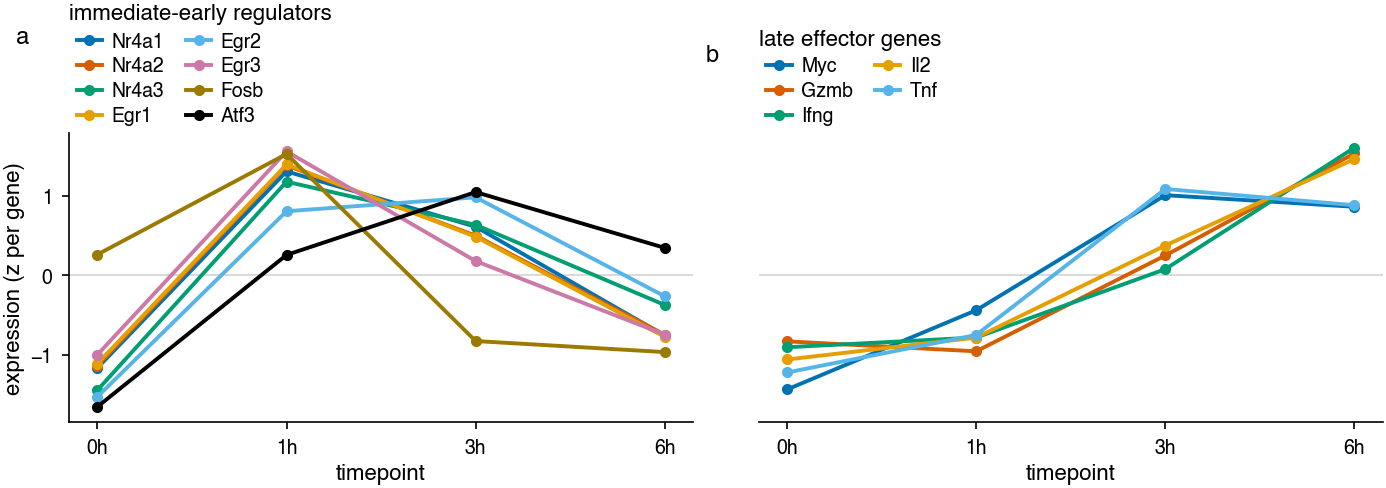

Fosb  1h=1.64  3h=0.11  -> 3h is 7% of the 1h level


In [5]:
# The SEM in these curves is deliberately zero: each point is already a
# per-timepoint mean, so there is no within-series spread to draw.
late_curves, _, late = pp.group_profiles(adata, LATE, "timepoint", order=TP_ORDER)

# `profiles_grid` places the panels, letters them and shares the y-axis, so the
# two marker sets cannot end up with each other's title.
fig, axes, _ = pp.profiles_grid(
    {"immediate-early regulators": early_curves, "late effector genes": late_curves},
    ticks=tp_ticks,
    xlabel="timepoint",
    ylabel="expression (z per gene)",
    legend_ncol=2,
)
plt.show()

# Quantify the transient rather than eyeball it: Fosb's 3 h level as a
# fraction of its 1 h peak.
fosb = early["Fosb"]
print(
    f"Fosb  1h={fosb['1h']:.2f}  3h={fosb['3h']:.2f}  "
    f"-> 3h is {100 * fosb['3h'] / fosb['1h']:.0f}% of the 1h level"
)

## 3. Building the views

Three views, each turning a different structure into hyperedges:

| view | what one hyperedge is |
|---|---|
| `tf` | cells in which one TF regulon (CollecTRI) is active |
| `pathway` | cells falling in one activity bin of one pathway (PROGENy) |
| `gene` | cells expressing one gene above a threshold |

The TF and pathway views need per-cell activity scores first.

In [6]:
from pathlib import Path

from pseudoembed.analysis.tf_hypergraph_drug_analysis import compute_tf_activities
from pseudoembed.core.multiview_hypergraph import compute_pathway_activities

# Cache the CollecTRI network to disk rather than re-fetching it.  `dc.op.collectri`
# pulls from Zenodo on every call, and Zenodo 504s intermittently -- two full runs
# of this notebook died on `504 Gateway Time-out` for the regulon CSV, minutes
# apart, with the same URL returning 200 in between.  A run that takes minutes
# should not stake itself on an upstream request it already made once.
_TF_CACHE = Path("_cache/collectri_mouse.csv")
if _TF_CACHE.exists():
    tf_net = pd.read_csv(_TF_CACHE)
    print(f"CollecTRI: {len(tf_net)} edges from cache {_TF_CACHE}")
else:
    import decoupler as dc

    tf_net = dc.op.collectri(organism="mouse")
    _TF_CACHE.parent.mkdir(parents=True, exist_ok=True)
    tf_net.to_csv(_TF_CACHE, index=False)
    print(f"CollecTRI: {len(tf_net)} edges fetched, cached to {_TF_CACHE}")

adata = compute_tf_activities(adata, organism="mouse", net=tf_net, verbose=False)
adata = compute_pathway_activities(adata, organism="mouse")

print("TF activities     :", adata.obsm["tf_activities"].shape)
print("Pathway activities:", adata.obsm["pathway_activities"].shape)
print("pathways:", adata.uns["pathway_activities_info"]["pathway_names"])

CollecTRI: 43226 edges from cache _cache/collectri_mouse.csv
COMPUTING PATHWAY ACTIVITIES
Loading PROGENy network for mouse...


2026-08-26 15:52:05 | [INFO] ulm - Running ulm


2026-08-26 15:52:05 | [INFO] Extracted omics mat with 250 rows (observations) and 15654 columns (features)


2026-08-26 15:52:05 | [INFO] Network adjacency matrix has 10116 unique features and 14 unique sources


2026-08-26 15:52:05 | [INFO] ulm - fitting 14 univariate models of 15654 observations (targets) with 15652 degrees of freedom


2026-08-26 15:52:05 | [INFO] ulm - adjusting p-values by FDR


2026-08-26 15:52:05 | [INFO] ulm - done


  Network: 60721 interactions
  Pathways: 14
  Target genes: 16706
Running ULM method...
✓ Computed activities for 14 pathways
  Stored in: adata.obsm['pathway_activities']
TF activities     : (250, 571)
Pathway activities: (250, 14)
pathways: ['Androgen', 'EGFR', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'p53']


## 4. Fit the hypergraph

Three library calls: build one hyperedge view per prior, pool them into one
aligned edge list, then fuse and read a pseudotime off the fusion.

`pathway_bins` is the parameter worth knowing about. It sets how many activity
bins each pathway is split into, and so how many cells one pathway hyperedge
spans. The library default (50) suits a few thousand cells; over 250 cells that
would leave ~5 cells per edge, so this tutorial passes 12 explicitly.

In [7]:
from pseudoembed import build_views, fit_pseudotime, pool_views
from pseudoembed.data.richard2018 import ROOT_MARKERS

# ROOT_MARKERS is a naive/quiescence panel (Sell, Klf2, Tcf7, Lef1, Ccr7) that
# seeds the trajectory. It is not an argmax: the library scores the panel, keeps
# cells above the 90th percentile, and roots on the lowest-degree cell in that
# pool.
ops, E, W, T, M = build_views(adata, views=("tf", "pathway", "gene"), pathway_bins=12)

# Pool the per-view bundles into ONE index-aligned edge list. Every
# interpretation function scores the pooled list, and the per-edge arrays must
# agree with the incidence matrix on what edge `i` is -- when they do not,
# nothing raises and a contribution is simply attributed to the wrong edge.
all_edges, all_weights, all_types, all_meta, H = pool_views(E, W, T, M)
print("pooled incidence H:", H.shape, "(cells x edges)")

BUILDING TF-BASED HYPERGRAPH
  Using 571 TFs for hypergraph construction
Adding TF programme edges (component_k=15)...
  Added 204 TF programme hyperedges
  Skipping TF-pair edges (include_pair_edges=False)

✓ Built hypergraph:
  Total hyperedges: 204
  Edge sizes: min=20, median=21, max=37
  Mean cells per edge: 21.9
  Co-activity: 0, Programme: 204, TF-pair: 0
BUILDING PATHWAY-BASED HYPERGRAPH
  Pathways: 14, bins per pathway: 12
✓ Built pathway hypergraph:
  Total hyperedges: 168
  Mean cells per edge: 20.8
BUILDING GENE-AS-HYPEREDGE HYPERGRAPH
  Candidate genes: 1200, z threshold: 1.0, 
  weighting: binary
✓ Built gene hypergraph:
  Total hyperedges: 666
  Dropped: 534 too small, 0 near-global
  Edge size: median 17 (6.8% of cells), max 58


view        n_edges  mean size
tf              204       21.9
pathway         168       20.8
gene            666       23.7

cells N = 250
pooled incidence H: (250, 1038) (cells x edges)


In [8]:
adata, P_fused, view_weights = fit_pseudotime(
    adata,
    ops,
    E,
    W,
    root_markers=ROOT_MARKERS,
    time_key="timepoint",
    condition_key="condition",
)

tau = adata.obs["multiview_pseudotime"].values
emb = adata.obsm["multiview_pseudotime_spectral"]
print("\nrho(pseudotime, hours) = %+.3f" % spearmanr(tau, adata.obs["hours"]).statistic)

COMPUTING MULTI-VIEW HYPERGRAPH SPECTRAL PSEUDOTIME
  Time points (categorical order): ['0h', '1h', '3h', '6h']
  Transition weights: same=1.0, forward=1.2, backward=0.3
Applying temporal bias...
Identifying root cell...
  Found 25 root candidates via marker genes
  Root cell index: 239
  Root cell type : n/a
Computing hypergraph spectral pseudotime (n_spectral_components=10, spectral_time_scale=4, method='geodesic')...
  Spectral decomposition converged — top eigenvalues: [0.8355 0.4574 0.2999 0.2427 0.1824 0.1448]
  Spectral gap (λ1−λ2): 0.3781
  Trivial-component test: mode='always' — dropping v0 as trivial
  Embedding scale='dpt' — top component weights: [0.314 0.16  0.119 0.083 0.063]
  Component classification reference: experimental time
  Component classification (|ρ| threshold=0.05): 7 maturation, 2 perturbation, 1 noise (dropped)
    v1: ρ_time=-0.899, ρ_cond=+0.207 → maturation
    v2: ρ_time=+0.129, ρ_cond=+0.773 → maturation
    v3: ρ_time=+0.204, ρ_cond=+0.305 → maturatio

### The three standard diagnostic panels

One call. Panels (a) and (b) read the *same* stored embedding and axis, so they
cannot disagree with each other — which is the reason this is a function in the
package rather than three inline figures.

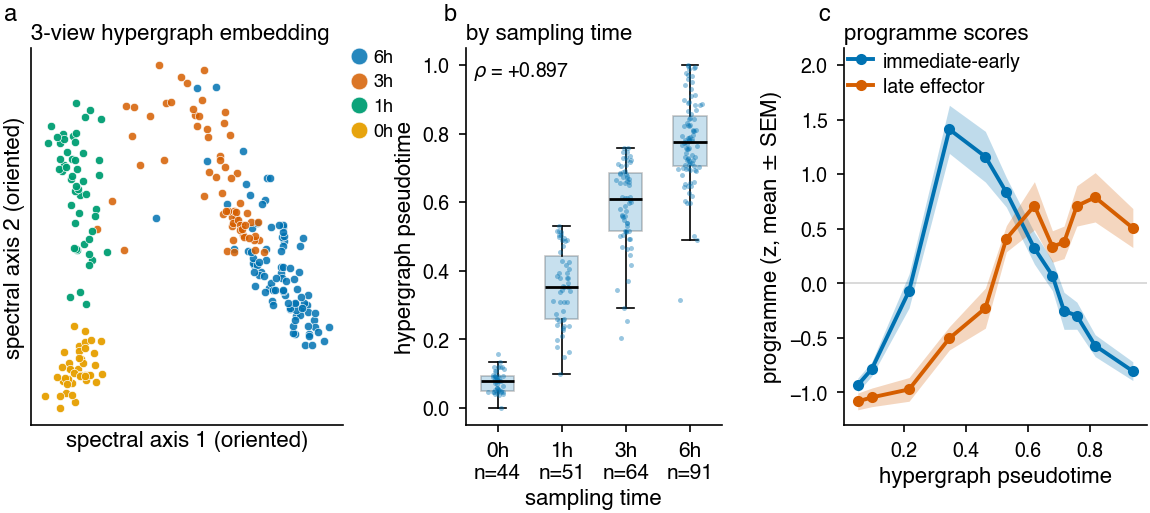

(0.8986140024495468, 0.1285051833812181)

In [9]:
from pseudoembed.plotting import bin_by_axis, profile_along_axis

# Programme scores to profile along the axis: the paper's two gene sets.
scores = {
    name: pp.panel_score(adata, present(adata, genes), name)
    for name, genes in [
        ("immediate-early", panels["early_TF"]),
        ("late effector", LATE),
    ]
}
binid, centres = bin_by_axis(tau, n_bins=12)
curves = {k: profile_along_axis(v, binid, n_bins=12) for k, v in scores.items()}

fig, axes, info = pp.standard_panels(
    emb,
    tau,
    adata.obs["timepoint"].astype(str).values,
    curves=curves,
    centres=centres,
    group_order=[c for c in adata.obs["timepoint"].cat.categories],
    group_name="sampling time",
    # `space_name` is derived from the views actually fitted, so relabelling the
    # fit cannot leave a stale method name on the figure.
    space_name=f"{len(ops)}-view hypergraph",
    reference=adata.obs["hours"].values,
    group_values=adata.obs["hours"].values,  # ordered, so rho is meaningful
    panel_c_title="programme scores",
)
plt.show()
info["orient_rho"]

## 5. Validate against held-out measurements

`hours` is not an independent check: the root is chosen with naive markers and
`time_key` is passed to the fitter, so the fit has seen sampling time indirectly.
The four index-sort protein measurements did **not** enter the model in any form,
which makes them the check worth running on a real result.

Expect CD69, CD25 and CD44 to rise with pseudotime and CD62L to fall — CD62L
(L-selectin) is shed on activation, so a *negative* correlation is the correct
biology, not a sign error.

In [10]:
PROTEINS = ["CD69", "CD25", "CD44", "CD62L"]
prot = pd.DataFrame(
    [
        {
            "protein": p,
            "rho vs pseudotime": round(
                spearmanr(tau, adata.obs[f"prot_{p}"]).statistic, 3
            ),
            "rho vs hours": round(
                spearmanr(adata.obs["hours"], adata.obs[f"prot_{p}"]).statistic, 3
            ),
            "expected sign": "-" if p == "CD62L" else "+",
        }
        for p in PROTEINS
    ]
)
prot["sign as expected"] = np.where(
    prot["expected sign"] == "+",
    prot["rho vs pseudotime"] > 0,
    prot["rho vs pseudotime"] < 0,
)
prot

,protein,rho vs pseudotime,rho vs hours,expected sign,sign as expected
0,CD69,0.868,0.880,+,True
1,CD25,0.814,0.825,+,True
2,CD44,0.342,0.372,+,True
3,CD62L,-0.531,-0.423,-,True


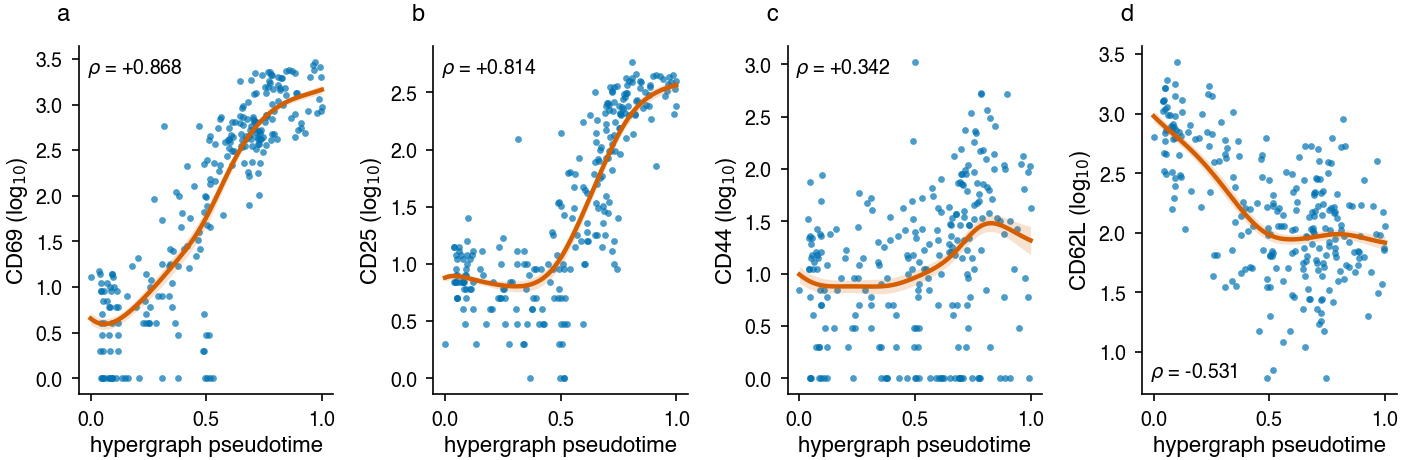

In [11]:
# One call, one panel per protein -- `scatter_grid` owns the figure, the panel
# letters and the shared x-axis, so there is no loop to keep in step here.
# trend="smooth" is a local linear regression (Gaussian kernel), not a straight
# line: CD62L falls steeply then flattens, and a fit that cannot bend reports it
# as weaker than it is.
fig, axes, prot_fits = pp.scatter_grid(
    tau,
    adata.obs[[f"prot_{p}" for p in PROTEINS]].rename(
        columns={f"prot_{p}": p for p in PROTEINS}
    ),
    xlabel="hypergraph pseudotime",
    ylabel_fmt="{name} (log$_{{10}}$)",
    trend="smooth",
    panel_h=2.5,
)
plt.show()

## 6. What drives the transition, read off the hyperedges

This is the part a pairwise graph cannot do. Every hyperedge carries a name — a
gene, a TF regulon, a pathway activity bin — so the axis decomposes into *named*
contributions, and the mean position of an edge's member cells gives that
programme an **onset**. Ordering edges by onset turns the model into a timeline
of named programmes running from early to late activation.

Two columns matter and they answer different questions.
`edge_axis_contributions` **squares** the projection, so `contrib_*` says how
much an edge moves the axis and is deliberately sign-blind. Direction lives only
in the signed columns, and of those only `signed_mean_*` is the per-member mean —
the raw `signed_*` grows with edge size, so it cannot compare a 21-cell pathway
edge with a 57-cell gene edge. Every early-versus-late claim below rests on
`signed_mean_phi1`.

In [12]:
from pseudoembed import edge_onset
from pseudoembed.core.hypergraph_interpret import edge_axis_contributions

# Column 0 of the embedding is the first RETAINED column, not necessarily the
# leading eigenvector; its sign is arbitrary, so fix it against real time before
# reading any direction off it.
rho_axis1 = spearmanr(emb[:, 0], adata.obs["hours"]).statistic
print("rho(spectral axis 1, hours) = %+.3f" % rho_axis1)

contrib = edge_axis_contributions(
    H,
    all_weights,
    emb[:, :3],
    hyperedge_types=all_types,
    hyperedge_meta=all_meta,
    axis_names=["phi1", "phi2", "phi3"],
)

# Onset: where each edge's member cells sit on the axis, and on the real clock.
# Merged on `edge_index`, never positionally -- edge_axis_contributions returns
# its rows sorted by contrib_total, so a positional join misattributes every row.
onset = edge_onset(all_edges, tau, adata.obs["hours"].values)
contrib = contrib.merge(
    onset.rename(columns={"onset": "onset_pseudotime", "onset_real": "onset_hours"}),
    on="edge_index",
    suffixes=("", "_dup"),
)

# `programme` is "view:name". `view` is a reserved pandas attribute, so it must
# be bracket-indexed (df["view"]) -- df.view returns a bound method on a row.
contrib["view"] = contrib["programme"].str.split(":").str[0]
contrib["name"] = contrib["edge_name"].str.split(":").str[-1]

# Orient so positive = late, whatever the eigenvector's arbitrary sign.
contrib["signed_late"] = contrib["signed_mean_phi1"] * (1.0 if rho_axis1 >= 0 else -1.0)
print("edges scored:", len(contrib))

rho(spectral axis 1, hours) = -0.899
edges scored: 1038


### The blind ranking

**No marker panel has been consulted at this point.** The views were built from
expression, a TF prior and a pathway prior; the axis came out of the fused
operator; the ranking below is whatever that axis says. The paper's gene lists
appear later in this section, and only to label a result already produced.

In [13]:
COLS = ["name", "view", "n_cells", "contrib_phi1", "signed_late", "onset_hours"]
late_end = contrib[contrib["signed_late"] > 0].nlargest(15, "contrib_phi1")
early_end = contrib[contrib["signed_late"] < 0].nlargest(15, "contrib_phi1")

print("=== LATE end: top 15 by contribution among late-signed edges ===")
print(late_end[COLS].to_string(index=False, float_format="%.3f"))
print("\n=== EARLY end: top 15 by contribution among early-signed edges ===")
print(early_end[COLS].to_string(index=False, float_format="%.3f"))

=== LATE end: top 15 by contribution among late-signed edges ===
    name    view  n_cells  contrib_phi1  signed_late  onset_hours
  Tnfsf8    gene       53         0.003        0.008        5.377
 Tnfrsf9    gene       57         0.003        0.007        4.789
   Rgs16    gene       49         0.003        0.007        5.020
    Ccl4    gene       50         0.003        0.007        5.060
    Ly6a    gene       52         0.003        0.007        5.308
    MAPK pathway       21         0.002        0.010        5.857
Serpinb9    gene       37         0.002        0.008        5.270
    Ccl3    gene       39         0.002        0.007        5.128
 Hypoxia pathway       21         0.002        0.010        6.000
    Cd44    gene       56         0.002        0.006        4.589
    PI3K pathway       21         0.002        0.010        6.000
   Itm2a    gene       56         0.002        0.006        4.482
   Gpr68    gene       57         0.002        0.006        4.298
    Lad1   

**What the two ends are.** The early end is the immediate-early TCR response —
`Fos` and `Fosb` (AP-1), `Dusp10` and `Btg2` (negative feedback on that
response), `Tsc22d3`, `Txnip` — alongside the naive/quiescence markers that
should be leaving: `Tcf7`, `S1pr1`, `Klf3`. Mean onset 0.5–1.1 h.

The late end is costimulation and effector signalling: `Tnfrsf9` (4-1BB) and
`Tnfsf8` (CD30L), the chemokines `Ccl3` and `Ccl4`, `Cd44` (the activation
marker independently confirmed by the held-out protein in §5), `Serpinb9`,
`Cish`, plus `Rgs16` and `Ly6a`. Mean onset 4.3–5.4 h. The three pathway edges
that reach this end — MAPK, PI3K, Hypoxia — are the canonical effector
differentiation signalling axes, so the pathway view corroborates the gene view
rather than repeating it.

Note what is *not* here: `Gzmb` and `Ifng` form eligible hyperedges (they are
detected in 52% and 35% of cells) but do not reach the top 15 by contribution.
At 6 hours post-stimulation that is the expected biology — this is the
activation programme, upstream of the cytolytic one. §"Coverage" below separates
"ranked low" from "never a candidate", which are different claims.

### The gradient, start to finish

Left: the top edges pulling to each end of the axis, taken **within each sign**
so both ends are represented — ranking by contribution alone would fill the
panel with whichever end dominates. Right: gene-view edges ordered by onset in
real hours, which is the same result read as a timeline.

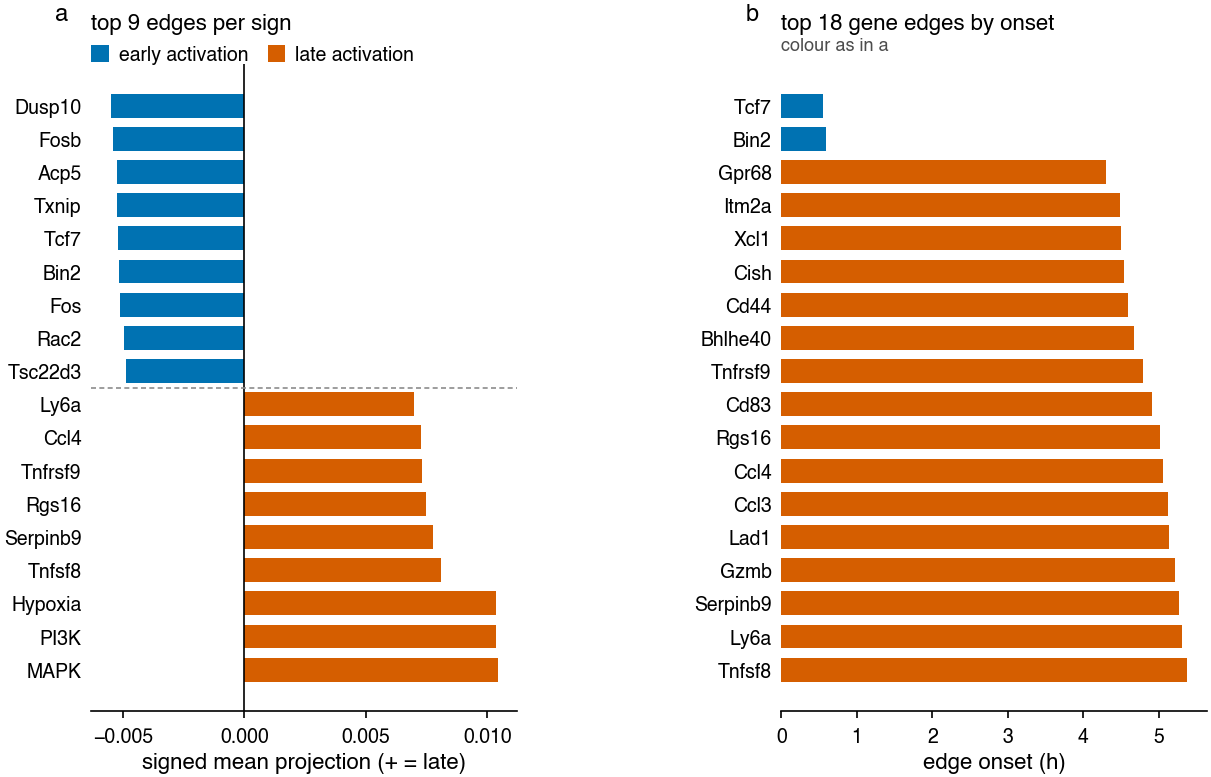

In [14]:
fig, axs = plt.subplots(
    1, 2, figsize=(S.W2, 4.2), gridspec_kw={"width_ratios": [1.0, 1.0], "wspace": 0.62}
)
# `signed_edge_split` reads `signed_mean_{axis_name}` directly, and phi1's sign is
# arbitrary -- here rho(axis 1, hours) is NEGATIVE, so raw-negative means LATE.
# Feed it the ORIENTED column under the name it expects, or the panel labels both
# ends backwards and contradicts panel (b).
oriented = contrib.assign(
    edge_name=contrib["name"], signed_mean_late=contrib["signed_late"]
)
sp = pp.signed_edge_split(
    axs[0],
    oriented,
    axis_name="late",
    n=9,
    side_labels=("early activation", "late activation"),
    palette={"early activation": S.BLUE, "late activation": S.VERMILLION},
    title="top 9 edges per sign",
)
# Assert the orientation rather than trust it: the top late-signed edge must be
# the one with the LATER mean onset. This figure was silently inverted once.
_late = sp[sp["side"] == "late activation"]["edge_name"].tolist()
_early = sp[sp["side"] == "early activation"]["edge_name"].tolist()
_on = contrib.set_index("name")["onset_hours"]
assert _on[_late].mean() > _on[_early].mean(), (
    f"panel (a) is inverted: 'late' edges {_late[:3]} have mean onset "
    f"{_on[_late].mean():.2f} h vs 'early' {_on[_early].mean():.2f} h"
)
axs[0].set_xlabel("signed mean projection (+ = late)")

# Gene edges only on the right: one edge = one gene, so the ladder is readable
# as a sequence of genes switching on.
ladder = (
    contrib[contrib["view"] == "gene"]
    .nlargest(18, "contrib_phi1")
    .sort_values("onset_hours")
)
axs[1].barh(
    np.arange(len(ladder)),
    ladder["onset_hours"].values,
    color=[S.BLUE if v < 0 else S.VERMILLION for v in ladder["signed_late"].values],
    height=0.72,
    edgecolor="none",
)
axs[1].set_yticks(np.arange(len(ladder)))
axs[1].set_yticklabels(ladder["name"].values)
axs[1].set_xlabel("edge onset (h)")
# barh draws y=0 at the BOTTOM, so an ascending sort reads latest-first from the
# top and contradicts the title.  invert_yaxis() puts earliest at the top, the
# reading order the title promises.  Do not add a later set_ylim -- it cancels
# this.
axs[1].invert_yaxis()
# Same title pad as panel (a), whose key occupies a row above its frame, so the
# two titles share one baseline instead of stepping.
axs[1].set_title("top 18 gene edges by onset", loc="left", pad=12.5)
# This panel reuses (a)'s two colours for the same early/late split, so say so:
# an unkeyed colour encoding beside a keyed one makes the reader guess whether
# the hues mean the same thing in both panels.
axs[1].text(
    0.0,
    1.015,
    "colour as in a",
    transform=axs[1].transAxes,
    fontsize=6.5,
    color=S.GREY,
    va="bottom",
    ha="left",
)
S.despine(axs[1], left=False)
for a, l in zip(axs, "ab"):
    S.panel_letter(a, l)
plt.show()

### Which view carries the axis

A view's share of the axis depends partly on how many hyperedges it was allowed
to build, so read the two panels together: the total share on the left, and the
mean contribution *per edge* on the right. `rank_changed` says whether
normalising by edge count reorders the views.

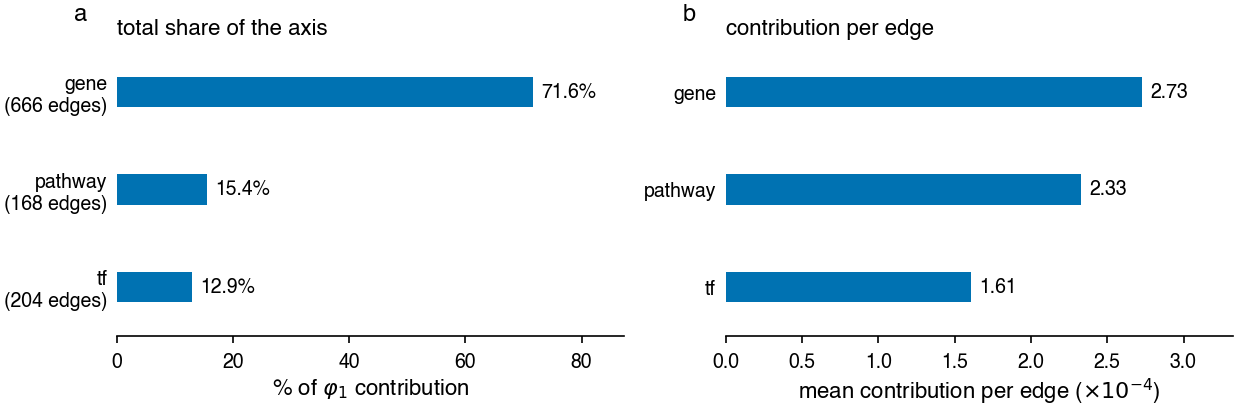

ranking changes when normalised per edge: False


,n_edges,total,pct,per_edge
view,,,,
gene,666,0.181557,71.634970,0.000273
pathway,168,0.039108,15.430362,0.000233
tf,204,0.032783,12.934668,0.000161


In [15]:
# Height set from the bar count: three categories in a 2.9in panel rendered as
# three slabs with the x-axis floating below them.  ~0.42in per bar plus the
# title/label furniture is the ratio that reads as a journal panel.
fig, axes = plt.subplots(1, 2, figsize=(S.W2, 1.9))
vs = pp.view_share(axes, contrib, contrib_col="contrib_phi1")
for a, l in zip(axes, "ab"):
    S.panel_letter(a, l)
plt.show()

print("ranking changes when normalised per edge:", vs["rank_changed"])
vs["table"]

### Genes, TFs and pathways separately

The same ranking split by view, because the three answer different questions: a
gene edge is one gene's high-expressing cells, a pathway edge is one activity
bin, a TF edge is one regulon's co-active cells.

Two caveats to carry into these tables.

**Edge size is not comparable across views.** Gene edges here average ~24 cells
but the top-ranked ones span 37–57, while every pathway and TF edge is ~21 by
construction. `contrib_phi1` is not size-normalised, so a small edge is
penalised on it; `signed_late` (the per-member mean) is the column that compares
fairly, and on that column the pathway edges score *higher* than the gene edges
they sit below.

**The TF view here is a footprint, not a validated regulon ranking.** Its edges
are cells co-active for an inferred regulon, and on this dataset the canonical
TCR-response regulators do not top that ranking — the immediate-early TFs
(`Fosb`, `Fos`) are recovered instead as **gene edges**, from their own
expression. Read the TF rows as a directional signal worth following up, not as
evidence about those TFs' regulons.

In [16]:
for v in ["gene", "pathway", "tf"]:
    sub = contrib[contrib["view"] == v]
    top = sub.nlargest(8, "contrib_phi1")[
        ["name", "n_cells", "contrib_phi1", "signed_late", "onset_hours"]
    ]
    print(
        f"--- {v} view: {len(sub)} edges, "
        f"mean size {sub['n_cells'].mean():.0f} cells ---"
    )
    print(top.to_string(index=False, float_format="%.3f"), "\n")

--- gene view: 666 edges, mean size 24 cells ---
    name  n_cells  contrib_phi1  signed_late  onset_hours
  Tnfsf8       53         0.003        0.008        5.377
 Tnfrsf9       57         0.003        0.007        4.789
   Rgs16       49         0.003        0.007        5.020
    Ccl4       50         0.003        0.007        5.060
    Ly6a       52         0.003        0.007        5.308
Serpinb9       37         0.002        0.008        5.270
    Ccl3       39         0.002        0.007        5.128
    Cd44       56         0.002        0.006        4.589 

--- pathway view: 168 edges, mean size 21 cells ---
   name  n_cells  contrib_phi1  signed_late  onset_hours
   MAPK       21         0.002        0.010        5.857
Hypoxia       21         0.002        0.010        6.000
   PI3K       21         0.002        0.010        6.000
   PI3K       21         0.001        0.009        5.857
    p53       21         0.001        0.010        6.000
Hypoxia       21         0.001   

### Does the blind ordering agree with the real clock?

The onset ordering above was produced from the fitted axis alone. Correlating it
against onset in *sampling hours* asks whether that ordering is a real timeline
or an artefact internal to the axis. This is the single number the section rests
on.

In [17]:
ge = contrib[contrib["view"] == "gene"]
r_onset = spearmanr(ge["onset_pseudotime"], ge["onset_hours"])
print(f"gene edges: n = {len(ge)}")
# Report an underflowed p as a bound, not as "p = 0": the exact value is below
# double precision, and printing a literal zero claims a p that was not computed.
p_txt = "< 1e-300" if r_onset.pvalue < 1e-300 else f"= {r_onset.pvalue:.2g}"
print(
    "rho(onset in pseudotime, onset in hours) = "
    f"{r_onset.statistic:+.3f}  (p {p_txt})"
)

gene edges: n = 666
rho(onset in pseudotime, onset in hours) = +0.965  (p < 1e-300)


### Cross-check: the paper's curated gene sets

Only now are the paper's lists brought in, and only to **label** the ranking
above — they did not select it. Fig 1e is the paper's early-response set and
`late_effector` its effector set; if the blind onset ordering is real, the two
should land in the right order on it.

Read the `n` on the panel before reading the p-value: the late arm is small
(`late_effector` has 5 genes and not all form an eligible edge), so this is a
consistency check, not an independent validation with weight of its own.

In [18]:
from pseudoembed import onset_group_test

gene_edges = contrib[contrib["view"] == "gene"].copy()
EARLY_SET = set(present(adata, panels["fig1e"]))
LATE_SET = set(present(adata, LATE))
gene_edges["phase"] = np.where(
    gene_edges["name"].isin(EARLY_SET),
    "early (Fig 1e)",
    np.where(gene_edges["name"].isin(LATE_SET), "late effector", None),
)

# Sorted by onset, because the FIGURE below draws rows in the order supplied and
# its entire claim is that the blind onset ranking separates the two curated sets.
# Left in contribution order the two colours interleave down the axis and the
# separation -- which the group test scores as real -- is invisible.  The group
# test itself is order-independent, so one sorted object serves both.
named = (
    gene_edges[gene_edges["phase"].notna()]
    .sort_values("onset_hours")
    .reset_index(drop=True)
)
print(
    named.groupby("phase")["onset_hours"].agg(["count", "median"]).round(2).to_string()
)
print()
print(
    onset_group_test(
        named,
        named["phase"],
        value_col="onset_hours",
        reference="late effector",
        alternative="less",
    ).to_string(index=False, float_format="%.4f")
)

                count  median
phase                        
early (Fig 1e)     12    1.58
late effector       3    4.96

         group  n  median     reference  n_reference  median_reference      U      p
early (Fig 1e) 12  1.5796 late effector            3            4.9630 0.0000 0.0022


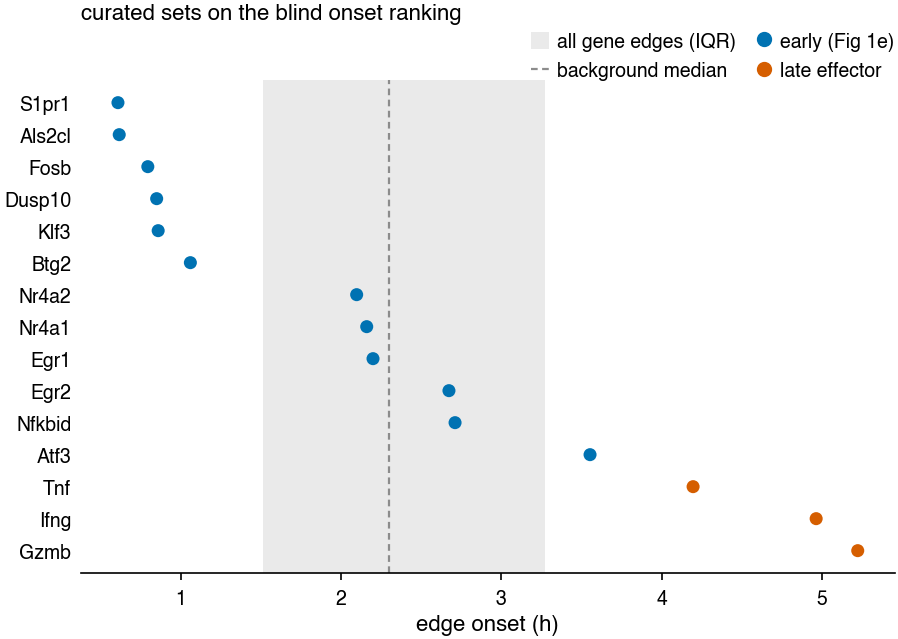

In [19]:
fig, ax = plt.subplots(figsize=(S.W1 * 1.5, 3.2))
# Same colour convention as the gradient figure above: blue = early, orange =
# late. Two figures in one section that swap the two colours is a real reading
# error, not a nitpick.
pal = {"early (Fig 1e)": S.BLUE, "late effector": S.VERMILLION}
n_e = int((named["phase"] == "early (Fig 1e)").sum())
n_l = int((named["phase"] == "late effector").sum())
oi = pp.onset_vs_background(
    ax,
    named,
    background=gene_edges["onset_hours"].values,
    value_col="onset_hours",
    label_col="name",
    group_col="phase",
    palette=pal,
    xlabel="edge onset (h)",
    # The legend now carries the two phases and their colours, so the n's would
    # be a third statement of the same split.  They are in the table above.
    title="curated sets on the blind onset ranking",
    band_label="all gene edges (IQR)",
)
# Single-panel figure -- a lone "a" labels nothing and collides with the title.
plt.show()

### Coverage: which genes could form an edge at all

Absence from the ranking has three different meanings, and they should not be
pooled. A gene forms a hyperedge only if it (i) is in the annotation, (ii) is
selected into the `n_genes=1200` candidate pool, and (iii) has between
`min_cells_per_edge` (10) and `gene_max_frac` (50%) of cells above its
expression hinge.

Gate (ii) is the one that surprises. It is a **selection** gate, not a detection
one: a gene can be detected in most cells and still never be offered as an edge,
because the pool is ranked before any edge is built. So a well-detected gene
missing from the ranking below has not been tested and found uninformative — it
was never a candidate. That is a coverage limit of this configuration, and the
fix is `n_genes`, or passing the panel explicitly via `genes=`.

In [20]:
from pseudoembed.core.multiview_hypergraph import select_gene_edge_pool

CYTOLYTIC = [
    "Gzmb",
    "Gzma",
    "Gzmk",
    "Prf1",
    "Ifng",
    "Nkg7",
    "Ctsw",
    "Klrd1",
    "Fasl",
    "Faslg",
    "Ccl3",
    "Ccl4",
    "Xcl1",
    "Serpinb9",
]
src = adata.raw.to_adata()
pool = set(select_gene_edge_pool(adata, n_genes=1200))
built = set(contrib.loc[contrib["view"] == "gene", "name"])

rows = []
for g in CYTOLYTIC:
    if g not in src.var_names:
        rows.append(
            {
                "gene": g,
                "detected in": "-",
                "in candidate pool": "-",
                "forms an edge": "no",
                "why not": "not annotated",
            }
        )
        continue
    x = src[:, g].X
    x = (
        np.asarray(x.todense()).ravel()
        if hasattr(x, "todense")
        else np.asarray(x).ravel()
    )
    in_pool = g in pool
    made = g in built
    rows.append(
        {
            "gene": g,
            "detected in": f"{(x > 0).mean():.0%}",
            "in candidate pool": "yes" if in_pool else "no",
            "forms an edge": "yes" if made else "no",
            "why not": ""
            if made
            else (
                "not selected into the pool"
                if not in_pool
                else "outside the edge-size window"
            ),
        }
    )
cov = pd.DataFrame(rows)
print(cov.to_string(index=False))
n_made = int((cov["forms an edge"] == "yes").sum())
print(
    f"\n{n_made}/{len(cov)} form a hyperedge. Of those that do not, the "
    "reason is in the last column -- and 'not selected into the pool' means "
    "untested, NOT uninformative."
)

    gene detected in in candidate pool forms an edge                      why not
    Gzmb         52%               yes           yes                             
    Gzma          1%               yes            no outside the edge-size window
    Gzmk           -                 -            no                not annotated
    Prf1         35%                no            no   not selected into the pool
    Ifng         35%               yes           yes                             
    Nkg7         89%               yes           yes                             
    Ctsw         63%                no            no   not selected into the pool
   Klrd1         63%                no            no   not selected into the pool
    Fasl          4%                no            no   not selected into the pool
   Faslg           -                 -            no                not annotated
    Ccl3         55%               yes           yes                             
    Ccl4        

### The same gradient as expression

The closing figure shows the transition directly. Rows are the **top-contributing
gene edges** — selected by the model, not by a curated list — ordered by **peak
position** along the axis, with a `*` marking the ones the paper happened to name.
The row order is derived by `axis_heatmap` from each row's own peak, not passed in:
ordering by contribution would give a visually random cascade, and ordering by
onset would be overridden by that peak sort anyway. Selecting rows by the
curated sets would be the prior recovering itself; here curation labels, it does
not choose.

Each row is a **kernel regression along pseudotime** rather than a set of bins,
so the gradient is continuous and the x-axis stays linear in the axis. Support is
still checked: any stretch of the axis holding fewer than `min_local` cells inside
one kernel width is drawn **grey** rather than interpolated across, so a gap in the
data reads as absent instead of as a smooth measurement. The smoothing runs along
each row only, never across rows — neighbouring rows are different genes and must
not be blended.

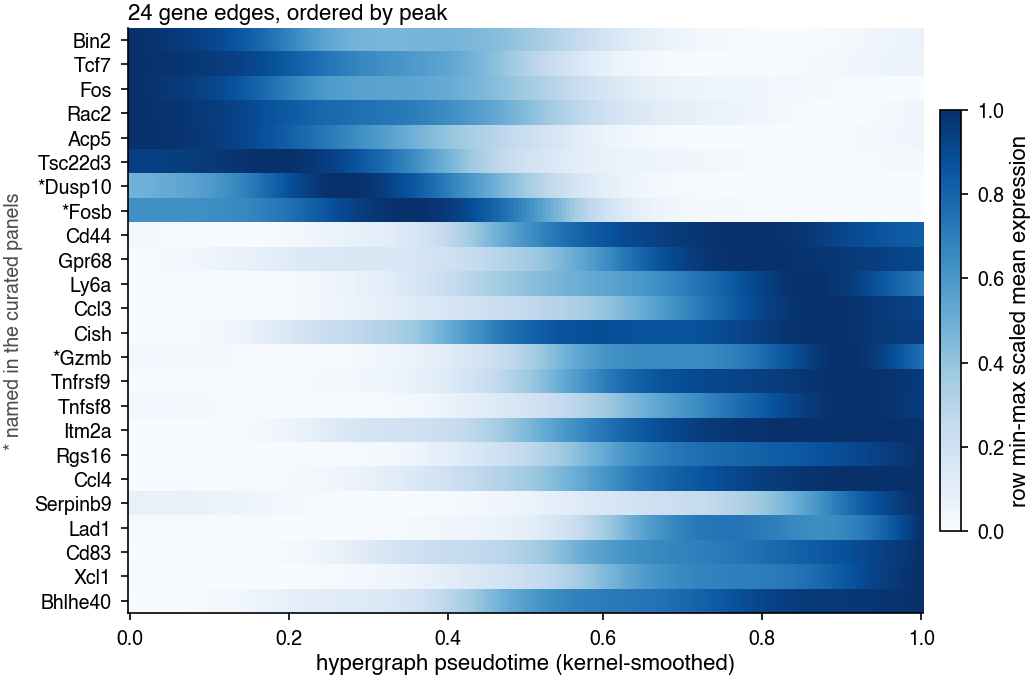

In [21]:
fig, ax = plt.subplots(figsize=(S.W2 * 0.75, 3.8))
# This list controls WHICH rows are shown, not their order: `axis_heatmap` re-sorts
# every row by peak position internally, so the onset sort that used to be here was
# discarded on the way in and only looked like it set the order.
hm_rows = (
    contrib[contrib["view"] == "gene"].nlargest(24, "contrib_phi1")["name"].tolist()
)
hm_rows = [g for g in hm_rows if g in adata.raw.var_names]
hsrc = adata.raw.to_adata()[:, hm_rows]
# mode="smooth" (the default): each row is a kernel regression along pseudotime,
# so the gradient reads continuously rather than as a handful of blocks. With 250
# cells the binned alternative needs a coarse n_bins to clear its min_cells floor,
# which is what made this figure look like isolated stripes. frac=0.08 sets the
# kernel width as a fraction of the axis, and any stretch of the axis holding
# fewer than min_local cells within one kernel width is left grey rather than
# interpolated across -- an unsupported gap must not be drawn as a gradient.
hm = pp.axis_heatmap(
    ax,
    pd.DataFrame(np.asarray(hsrc.X), columns=hsrc.var_names),
    tau,
    hm_rows,
    mode="smooth",
    frac=0.08,
    curated={g: "early (Fig 1e)" for g in EARLY_SET}
    | {g: "late effector" for g in LATE_SET},
    axis_name="hypergraph pseudotime",
)
plt.show()
if hm["dropped_low_detection"]:
    # Named, never silent: a dropped row is a filter, not a biological absence.
    print("rows dropped (too few detecting cells):", hm["dropped_low_detection"])

### TF and pathway activity along the same axis

The gradient above is expression. The other two views score **activity**, and both
are worth reading on the same axis: a TF footprint says which regulators are
inferred active from their targets, and a PROGENy score says which signalling
pathways are responding. Neither is expression of the TF or pathway gene itself.

Three things differ from the expression heatmap and change how the panels are
built:

* **Zero is the middle of the scale, not the floor.** An activity score goes
  negative when a regulator is inferred *repressed*. So rows are z-scored and drawn
  on a **diverging** ramp, and `signed_values=True` switches the detection floor
  from `> 0` to `!= 0` — without it a uniformly repressed regulator measures 0%
  detected and is silently dropped, which deletes exactly the rows whose
  down-regulation is the finding.
* **TF rows are chosen blind, pathway rows are not chosen at all.** TFs are ranked
  by the contribution of their own hyperedge to the axis. There are only ~14 PROGENy
  pathways, so all of them are shown — ranking a set that small would hide the
  negatives, and a pathway that does *not* move is a result here.
* **A view can rank an edge highly without the activity itself being monotone.**
  §6 showed the TF view carries only 12.9% of the axis, so treat a flat TF row as
  the honest answer rather than a failed panel.

In [22]:
# Both matrices are already on `adata` from S3 -- do not recompute them here.
# They are stored as plain ARRAYS; the column names live in `uns['{key}_info']`,
# so index by position via the name list rather than expecting a DataFrame.
tf_act = np.asarray(adata.obsm["tf_activities"])
pw_act = np.asarray(adata.obsm["pathway_activities"])
tf_names = list(adata.uns["tf_activities_info"]["tf_names"])
pw_names = list(adata.uns["pathway_activities_info"]["pathway_names"])
assert tf_act.shape[1] == len(tf_names), "TF matrix and name list disagree"
assert pw_act.shape[1] == len(pw_names), "pathway matrix and name list disagree"
tf_col = {t: i for i, t in enumerate(tf_names)}
print(f"TF activities: {tf_act.shape[1]} regulons | pathways: {pw_act.shape[1]}")

# TF rows: ranked by their OWN hyperedge's contribution, so the selection is the
# model's, not a curated list. Intersect with the scored regulons -- a TF edge can
# exist for a regulon whose activity column was dropped upstream.
tf_rank = contrib[contrib["view"] == "tf"].sort_values("contrib_phi1", ascending=False)
tf_rows = [t for t in tf_rank["name"] if t in tf_col][:18]
# Do NOT sort these by onset: `axis_heatmap` re-sorts every row by PEAK position
# internally, so any order passed in is discarded. Sorting here would look like it
# set the row order and quietly not do so. Peak order is the derived one and is
# what produces the cascade; selection is what this list controls.
n_missing = int((~tf_rank["name"].isin(tf_col)).sum())
print(
    f"TF edges ranked: {len(tf_rank)} | shown: {len(tf_rows)} | "
    f"ranked but unscored: {n_missing}"
)

TF activities: 571 regulons | pathways: 14
TF edges ranked: 204 | shown: 18 | ranked but unscored: 0


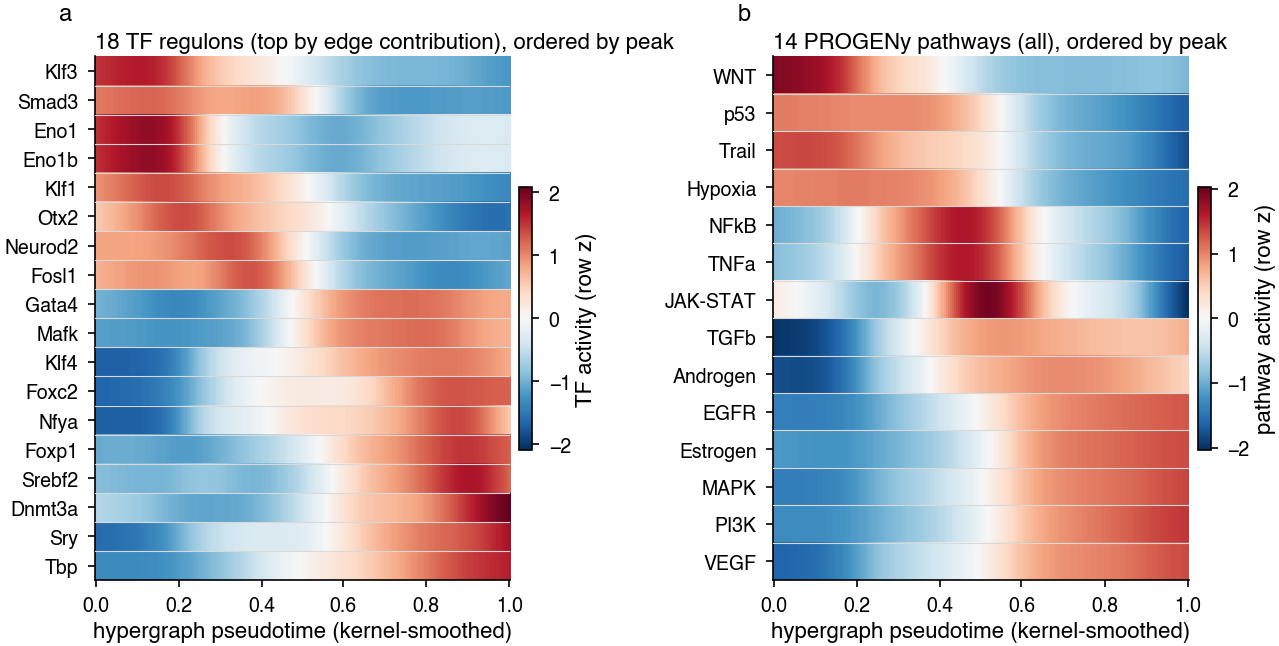

In [23]:
fig, axs = plt.subplots(
    1, 2, figsize=(S.W2, 3.4), gridspec_kw={"width_ratios": [1.0, 1.0], "wspace": 0.55}
)

# scale="zscore" pairs with signed_values=True: the quantity diverges about zero,
# so a sequential ramp would put the neutral value at an arbitrary lightness and
# invent an ordering the data does not have.
tf_hm = pp.axis_heatmap(
    axs[0],
    tf_act[:, [tf_col[t] for t in tf_rows]],
    tau,
    tf_rows,
    mode="smooth",
    frac=0.08,
    scale="zscore",
    signed_values=True,
    axis_name="hypergraph pseudotime",
    cbar_label="TF activity (row z)",
    # `row_noun` rather than a set_title override: the auto-title also carries the
    # grey-gap warning when part of the axis is unsupported, and overriding it
    # throws that warning away.
    row_noun="TF regulons (top by edge contribution)",
)

# EVERY pathway -- not a top-k. With ~14 of them a ranking would hide the ones that
# do not move, and a flat pathway is a result. Row order is the peak sort applied
# inside `axis_heatmap`.
pw_hm = pp.axis_heatmap(
    axs[1],
    pw_act,
    tau,
    pw_names,
    mode="smooth",
    frac=0.08,
    scale="zscore",
    signed_values=True,
    axis_name="hypergraph pseudotime",
    cbar_label="pathway activity (row z)",
    row_noun="PROGENy pathways (all)",
)

for a, l in zip(axs, "ab"):
    S.panel_letter(a, l)
plt.show()

for nm, h in [("TF", tf_hm), ("pathway", pw_hm)]:
    if h["dropped_low_detection"]:
        print(f"{nm} rows dropped:", h["dropped_low_detection"])